### <b><center>ELG5271: AI for Cybersecurity application <br>Project: Adaptive and Failure-Aware Adversarial Defense for Machine-Learning-Based Intrusion Detection Systems
#### <b><center> Group 4:<br> </b> Karamoko Soumare #:300203291 <br> Elame Olame Mugabo #: <br>Ingrid Fortune Kengfack Zemdem #: <br>Serge Gabin Talom Defo #: <br>

### Project Workflow: 
This project develops an adaptive and failure-aware adversarial defense framework for intrusion detection systems (IDS). The workflow follows a structured pipeline from data preparation to robustness evaluation.

#### Workflow Overview

1. **Data Preparation**  
   Load and preprocess the CIC-IDS2017 dataset, ensuring clean, normalized, and balanced data for training and evaluation.

2. **Baseline Model Training**  
   Train an XGBoost classifier on clean data to establish a reference IDS performance.

3. **Adversarial Attack Generation**  
   Generate adversarial examples using FGSM and PGD to simulate evasion attacks under realistic constraints.

4. **Baseline Evaluation**  
   Evaluate the model on clean and adversarial data using metrics such as F1-score, PR-AUC, and Attack Success Rate (ASR).

5. **Model Behavior Analysis**  
   Compute reliability indicators including prediction confidence, uncertainty, and stability under perturbations.

6. **Failure Detection**  
   Identify unreliable predictions based on low confidence, high uncertainty, or unstable outputs.

7. **Adaptive Defense Mechanism**  
   Dynamically select defense strategies (no defense, FGSM, PGD, retraining) based on model behavior.

8. **Vulnerability-Driven GAN Training**  
   Generate synthetic samples near fragile decision regions to reinforce weak areas of the model.

9. **Iterative Model Refinement**  
   Retrain the model using adversarial and GAN-generated data to improve robustness.

10. **Final Evaluation and Analysis**  
    Compare adaptive defense against static methods and analyze performance across attack scenarios.

#### Pipeline Summary

Data -> Model Training -> Adversarial Attacks -> Evaluation -> 
Behavior Analysis -> Adaptive Defense -> GAN Reinforcement -> Retraining -> Final Evaluation

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import f_classif, mutual_info_classif, SelectKBest
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from xgboost import XGBClassifier

#### 1. **Data Preparation** 
- Load CIC-IDS2017 dataset
- Handle missing values and remove invalid samples
- Encode categorical features (if any)
- Normalize / standardize numerical features
- Split data using stratified k-fold cross-validation (k=5)

In [2]:
# Load the datasets
data1 = pd.read_csv('archive/Monday-WorkingHours.pcap_ISCX.csv')
data2 = pd.read_csv('archive/Tuesday-WorkingHours.pcap_ISCX.csv')
data3 = pd.read_csv('archive/Wednesday-WorkingHours.pcap_ISCX.csv')
data4 = pd.read_csv('archive/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv')
data5 = pd.read_csv('archive/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv')
data6 = pd.read_csv('archive/Friday-WorkingHours-Morning.pcap_ISCX.csv')
data7 = pd.read_csv('archive/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv')
data8 = pd.read_csv('archive/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')

In [3]:
data1.shape, data2.shape, data3.shape, data4.shape, data5.shape, data6.shape, data7.shape, data8.shape

((529918, 79),
 (445909, 79),
 (692703, 79),
 (170366, 79),
 (288602, 79),
 (191033, 79),
 (286467, 79),
 (225745, 79))

In [4]:
# Merge the datasets
data = pd.concat([data1, data2, data3, data4, data5, data6, data7, data8], ignore_index=True)
data.shape
data.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [5]:
# Handle missing values
# Check for missing values and drop rows with missing values
data = data.dropna()

# Replace infinite values with NaN, then drop them
data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna()

data.shape
data.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [6]:
# Remove invalid values
# Check for invalid values in the 'Label' column and remove rows with invalid values
data.columns = data.columns.str.strip()
data['Label'].value_counts()

Label
BENIGN                        2271320
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [7]:
# Encode the labels : BENIGN = 0, ATTACK = 1
data['Label'] = data['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)
data['Label'].value_counts()

Label
0    2271320
1     556556
Name: count, dtype: int64

In [8]:
# Split the data into features and labels
X = data.drop('Label', axis=1)
y = data['Label']

In [9]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [10]:
# Feature normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

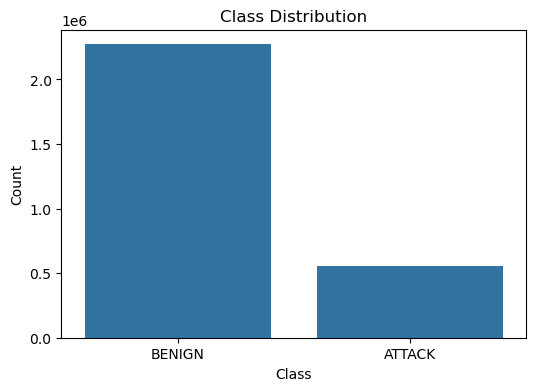

Percentage of ATTACK samples: 19.68%


In [11]:
# Dataset exploration
# Class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Label', data=data)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks([0, 1], ['BENIGN', 'ATTACK'])
plt.show()

# Attack percentage
attack_percentage = data['Label'].mean() * 100
print(f"Percentage of ATTACK samples: {attack_percentage:.2f}%")


#### <b>1.2) <u>Feature Engineering

In [12]:
# Feature Engineering
# Analyze feature importance using Annova F-test

f_values, p_values = f_classif(X_train_scaled, y_train)
feature_importance = pd.DataFrame({'Feature': X.columns, 'F-value': f_values, 'p-value': p_values})
feature_importance = feature_importance.sort_values(by='F-value', ascending=False)
print(feature_importance.head(30))   

                   Feature        F-value  p-value
13   Bwd Packet Length Std  799574.291821      0.0
10   Bwd Packet Length Max  725773.922914      0.0
12  Bwd Packet Length Mean  695827.320483      0.0
54    Avg Bwd Segment Size  695827.320483      0.0
41       Packet Length Std  644954.624529      0.0
39       Max Packet Length  590108.047585      0.0
42  Packet Length Variance  588090.238491      0.0
22             Fwd IAT Std  493867.971658      0.0
40      Packet Length Mean  469897.069477      0.0
52     Average Packet Size  467169.995548      0.0
76                Idle Max  417548.114705      0.0
74               Idle Mean  408195.422374      0.0
18            Flow IAT Max  403750.159109      0.0
23             Fwd IAT Max  403702.826455      0.0
77                Idle Min  384458.217719      0.0
17            Flow IAT Std  289867.023541      0.0
38       Min Packet Length  226084.970862      0.0
11   Bwd Packet Length Min  194915.631989      0.0
20           Fwd IAT Total  110

In [13]:
# Mutual information for feature importance
mi_scores = mutual_info_classif(X_train_scaled, y_train, n_neighbors=3, n_jobs=-1)
mi_importance = pd.DataFrame({'Feature': X.columns, 'MI Score': mi_scores})
mi_importance = mi_importance.sort_values(by='MI Score', ascending=False)
print(mi_importance.head(30))

                        Feature  MI Score
52          Average Packet Size  0.352205
41            Packet Length Std  0.351447
42       Packet Length Variance  0.351314
40           Packet Length Mean  0.325157
0              Destination Port  0.322399
12       Bwd Packet Length Mean  0.304327
54         Avg Bwd Segment Size  0.303848
66       Init_Win_bytes_forward  0.299179
65            Subflow Bwd Bytes  0.296902
5   Total Length of Bwd Packets  0.296892
63            Subflow Fwd Bytes  0.285750
4   Total Length of Fwd Packets  0.285680
10        Bwd Packet Length Max  0.272042
67      Init_Win_bytes_backward  0.271310
39            Max Packet Length  0.267991
13        Bwd Packet Length Std  0.264407
6         Fwd Packet Length Max  0.251241
53         Avg Fwd Segment Size  0.216474
8        Fwd Packet Length Mean  0.216248
18                 Flow IAT Max  0.212455
14                 Flow Bytes/s  0.209332
9         Fwd Packet Length Std  0.207609
1                 Flow Duration  0

In [14]:
# Cross-validate Annova and Mutual Information results to select top 30 features
k=30
top_mi = set(mi_importance.head(k)['Feature'])
top_anova = set(feature_importance.head(k).Feature)
final_features = sorted(top_anova.intersection(top_mi))

print("Final selected features:", final_features)

Final selected features: ['Average Packet Size', 'Avg Bwd Segment Size', 'Bwd Packet Length Max', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Destination Port', 'Flow Duration', 'Flow IAT Max', 'Fwd IAT Max', 'Fwd IAT Std', 'Fwd IAT Total', 'Idle Max', 'Idle Mean', 'Idle Min', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance']


#### 2.**Baseline Model Training**
- XGBoost classifier (baseline)
- Train model on clean training data
- Tune hyperparameters (optional: grid search or CV)
- Save trained model


In [15]:
# Xgboost model
model = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42
)

model.fit(X_train_scaled, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [16]:
# Train the model and make predictions
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

Precision: 0.9974
Recall: 0.9990
F1-score: 0.9982
ROC-AUC: 1.0000
PR-AUC: 0.9999
False Positive Rate (FPR): 0.0006


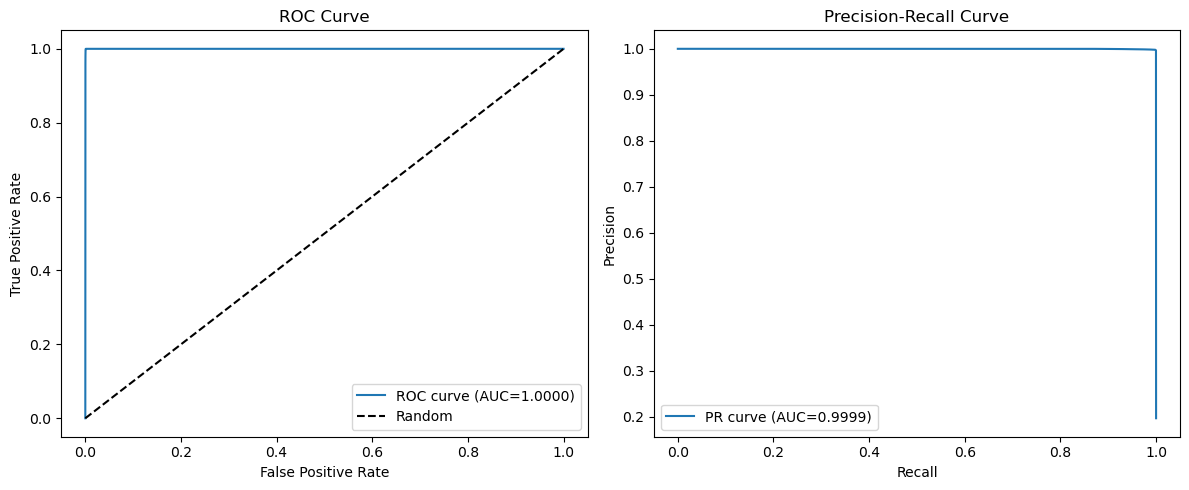

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    454265
           1       1.00      1.00      1.00    111311

    accuracy                           1.00    565576
   macro avg       1.00      1.00      1.00    565576
weighted avg       1.00      1.00      1.00    565576

ROC AUC Score: 0.9999750642303015
Average Precision Score: 0.999894018154631


In [17]:
# Baseline evaluation
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, precision_recall_curve, auc
)

# Point metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_proba)

# PR-AUC (area under Precision-Recall curve)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_curve, precision_curve)

# False Positive Rate
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
false_positive_rate = fp / (fp + tn)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {auc_roc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
print(f"False Positive Rate (FPR): {false_positive_rate:.4f}")

# Curves for plotting
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(12, 5))

# ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f"ROC curve (AUC={auc_roc:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

# Precision-Recall Curve
plt.subplot(1, 2, 2)
plt.plot(recall_curve, precision_curve, label=f"PR curve (AUC={pr_auc:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.tight_layout()
plt.show()
print(classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))
print("Average Precision Score:", average_precision_score(y_test, y_proba))

#### 4.**Adversarial Attack generation**
- Objective: Simulate adversarial evasion attacks on IDS inputs.

- Attacks Implemented
    - FGSM (single-step attack)
    - PGD (multi-step iterative attack)

- For each input sample `x`:
    1. Compute gradient of loss w.r.t input
    2. Generate adversarial perturbation:
        - FGSM
        - PGD
    3. Enforce feature constraints

In [18]:
# FGSM implementation: Option 1 - Finite difference approximation of the gradient
def fgsm_attack_xgb(model, X, y, epsilon=0.01, delta=1e-4):
    # Support both numpy arrays and DataFrames
    X_arr = X if isinstance(X, np.ndarray) else X.values
    X_adv = X_arr.copy().astype(float)

    for i in range(len(X_arr)):
        x = X_arr[i].copy()
        grad = np.zeros_like(x)

        # Finite difference approximation of the gradient
        for j in range(len(x)):
            x_plus = x.copy()
            x_plus[j] += delta

            pred1 = model.predict_proba(x.reshape(1, -1))[0][1]
            pred2 = model.predict_proba(x_plus.reshape(1, -1))[0][1]

            grad[j] = (pred2 - pred1) / delta

        # Create adversarial example
        X_adv[i] = x + epsilon * np.sign(grad)

    return X_adv

In [19]:
# FGSM Option 2 — surrogate mimics victim probabilities on TRAIN only; perturbations from
# gradient of BCE(w.r.t. true label) so the step increases loss (untargeted FGSM).
def fgsm_attack_surrogate(victim_model, X_attack, y_attack, X_surrogate, epsilon=0.001, surrogate_epochs=10,  surrogate_net=None,):
    import torch

    def _to_numpy(X):
        return X if isinstance(X, np.ndarray) else X.values

    X_sur = _to_numpy(X_surrogate).astype(np.float32)
    X_att = _to_numpy(X_attack).astype(np.float32)
    n_features = X_sur.shape[1]
    if X_att.shape[1] != n_features:
        raise ValueError("X_attack and X_surrogate must have the same number of features")

    y_att = y_attack.values if hasattr(y_attack, "values") else y_attack
    y_att = np.asarray(y_att, dtype=np.float32).reshape(-1, 1)

    if surrogate_net is None:
        p_victim = victim_model.predict_proba(X_sur)[:, 1:2].astype(np.float32)
        surrogate = torch.nn.Sequential(
            torch.nn.Linear(n_features, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 1),
            torch.nn.Sigmoid(),
        )
        criterion_train = torch.nn.BCELoss()
        optimizer = torch.optim.Adam(surrogate.parameters(), lr=0.001)
        X_train_t = torch.tensor(X_sur, dtype=torch.float32)
        y_teacher_t = torch.tensor(p_victim, dtype=torch.float32)
        for _ in range(surrogate_epochs):
            surrogate.train()
            optimizer.zero_grad()
            outputs = surrogate(X_train_t)
            loss = criterion_train(outputs, y_teacher_t)
            loss.backward()
            optimizer.step()
    else:
        surrogate = surrogate_net

    X_adv = X_att.copy()
    surrogate.eval()
    bce = torch.nn.BCELoss()
    for i in range(len(X_att)):
        x_tensor = (
            torch.tensor(X_att[i], dtype=torch.float32).unsqueeze(0).requires_grad_(True)
        )
        y_i = torch.tensor(y_att[i], dtype=torch.float32).view(1, 1)
        pred = surrogate(x_tensor)
        loss_attack = bce(pred, y_i)
        loss_attack.backward()
        grad = x_tensor.grad.squeeze(0).detach().cpu().numpy()
        X_adv[i] = X_att[i] + epsilon * np.sign(grad)
        X_adv[i] = np.clip(X_adv[i], 0, 1)

    return X_adv, surrogate

In [20]:
#FGSM attack using finite difference approximation
# X_test_adv_finite = fgsm_attack_xgb(model, X_test_scaled, y_test, epsilon=0.01)
# y_pred_adv_finite = model.predict(X_test_adv_finite)
# y_proba_adv_finite = model.predict_proba(X_test_adv_finite)[:, 1]

In [21]:
# FGSm attack using surrogate model (surrogate fit on train only; attack on test)
X_test_adv_surrogate, _ = fgsm_attack_surrogate(
    model, X_test_scaled, y_test, X_train_scaled, epsilon=0.000001, surrogate_epochs=10
)
y_pred_adv_surrogate = model.predict(X_test_adv_surrogate)
y_proba_adv_surrogate = model.predict_proba(X_test_adv_surrogate)[:, 1]

=== FGSM Attack (Surrogate Model) ===
Precision under FGSM:              0.0000
Recall under FGSM:                 0.0000
F1-score under FGSM:               0.0000
ROC-AUC under FGSM:                0.8026
PR-AUC under FGSM:                 0.4797
False Positive Rate under FGSM:    0.0000

              precision    recall  f1-score   support

           0       0.80      1.00      0.89    454265
           1       0.00      0.00      0.00    111311

    accuracy                           0.80    565576
   macro avg       0.40      0.50      0.45    565576
weighted avg       0.65      0.80      0.72    565576



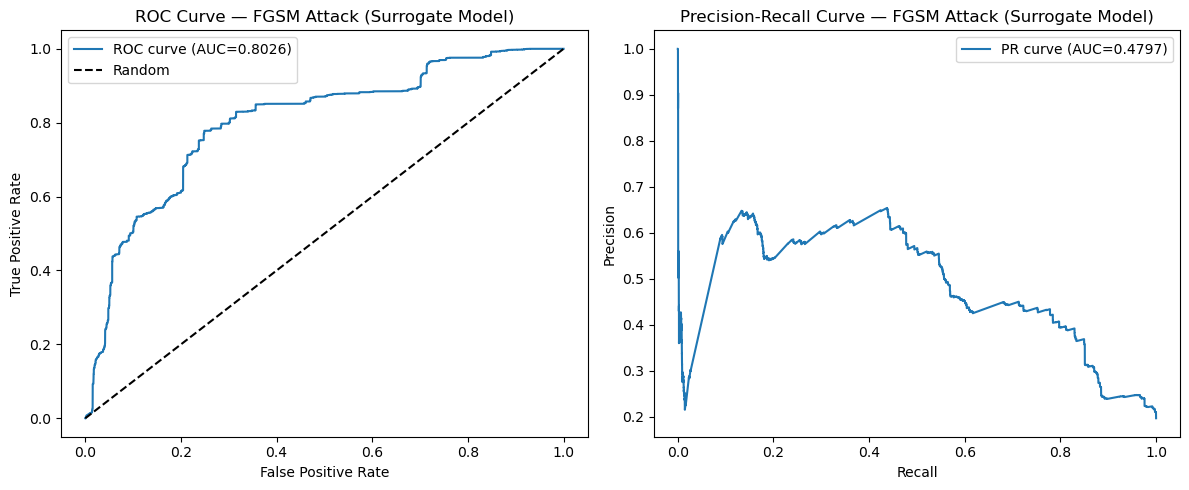

In [22]:
def evaluate_model(y_true, y_pred, y_proba, title="Model Evaluation", attack=None):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc_roc = roc_auc_score(y_true, y_proba)

    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_proba)
    pr_auc = auc(recall_curve, precision_curve)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    false_positive_rate = fp / (fp + tn)

    tag = f" under {attack}" if attack else ""

    print(f"=== {title} ===")
    print(f"Precision{tag}:              {precision:.4f}")
    print(f"Recall{tag}:                 {recall:.4f}")
    print(f"F1-score{tag}:               {f1:.4f}")
    print(f"ROC-AUC{tag}:                {auc_roc:.4f}")
    print(f"PR-AUC{tag}:                 {pr_auc:.4f}")
    print(f"False Positive Rate{tag}:    {false_positive_rate:.4f}")
    print()
    print(classification_report(y_true, y_pred))

    fpr_curve, tpr_curve, _ = roc_curve(y_true, y_proba)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(fpr_curve, tpr_curve, label=f"ROC curve (AUC={auc_roc:.4f})")
    plt.plot([0, 1], [0, 1], "k--", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {title}")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(recall_curve, precision_curve, label=f"PR curve (AUC={pr_auc:.4f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve — {title}")
    plt.legend()

    plt.tight_layout()
    plt.show()

# Evaluate FGSM (finite difference)
# evaluate_model(y_test, y_pred_adv_finite, y_proba_adv_finite,
#                title="FGSM Attack (Finite Difference)", attack="FGSM")

# Evaluate FGSM (surrogate model)
evaluate_model(y_test, y_pred_adv_surrogate, y_proba_adv_surrogate,
               title="FGSM Attack (Surrogate Model)", attack="FGSM")

epsilon=0.000001  F1=0.0000  ROC-AUC=0.7785  PR-AUC=0.4999  FPR=0.0000  ASR=1.0000
epsilon=0.000010  F1=0.0000  ROC-AUC=0.8111  PR-AUC=0.5820  FPR=0.0000  ASR=1.0000
epsilon=0.000100  F1=0.0000  ROC-AUC=0.8317  PR-AUC=0.6457  FPR=0.0000  ASR=1.0000
epsilon=0.001000  F1=0.0000  ROC-AUC=0.8795  PR-AUC=0.7176  FPR=0.0000  ASR=1.0000
epsilon=0.010000  F1=0.0000  ROC-AUC=0.8833  PR-AUC=0.7289  FPR=0.0000  ASR=1.0000


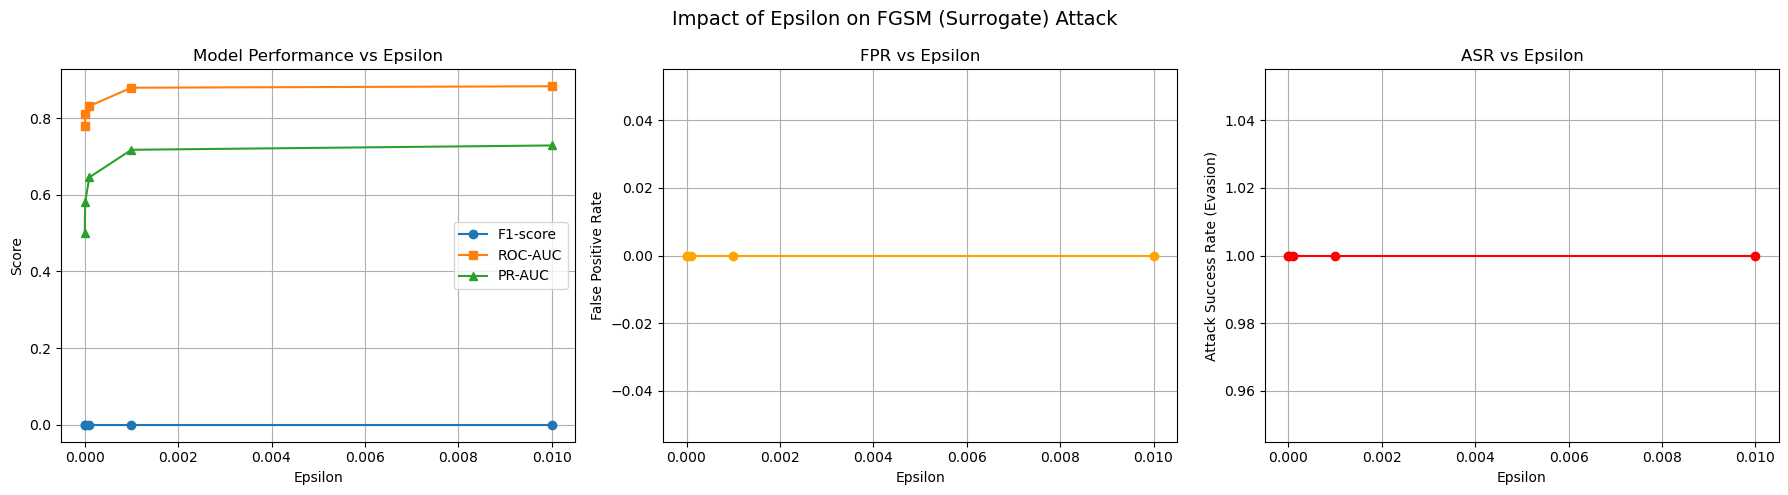

In [23]:
# Impact of epsilon on FGSM (surrogate) attack
epsilons = [0.000001, 0.00001, 0.0001, 0.001, 0.01]

y_pred_clean = model.predict(X_test_scaled)
y_test_arr = y_test.values

results = []
fgsm_surrogate = None
for eps in epsilons:
    X_adv, fgsm_surrogate = fgsm_attack_surrogate(
        model,
        X_test_scaled,
        y_test,
        X_train_scaled,
        epsilon=eps,
        surrogate_epochs=10,
        surrogate_net=fgsm_surrogate,
    )
    y_pred_adv = model.predict(X_adv)
    y_proba_adv = model.predict_proba(X_adv)[:, 1]

    f1 = f1_score(y_test, y_pred_adv)
    auc_roc = roc_auc_score(y_test, y_proba_adv)
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba_adv)
    pr_auc = auc(recall_curve, precision_curve)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_adv).ravel()
    fpr_val = fp / (fp + tn)

    # ASR: among ATTACK samples correctly classified originally, fraction flipped to BENIGN (evasion)
    attack_correct_mask = (y_pred_clean == y_test_arr) & (y_test_arr == 1)
    asr = np.mean(y_pred_adv[attack_correct_mask] != y_test_arr[attack_correct_mask])

    results.append({
        'epsilon': eps, 'F1': f1, 'ROC-AUC': auc_roc,
        'PR-AUC': pr_auc, 'FPR': fpr_val, 'ASR': asr
    })
    print(f"epsilon={eps:.6f}  F1={f1:.4f}  ROC-AUC={auc_roc:.4f}  PR-AUC={pr_auc:.4f}  FPR={fpr_val:.4f}  ASR={asr:.4f}")

results_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Impact of Epsilon on FGSM (Surrogate) Attack", fontsize=14)

axes[0].plot(results_df['epsilon'], results_df['F1'], marker='o', label='F1-score')
axes[0].plot(results_df['epsilon'], results_df['ROC-AUC'], marker='s', label='ROC-AUC')
axes[0].plot(results_df['epsilon'], results_df['PR-AUC'], marker='^', label='PR-AUC')
axes[0].set_xlabel("Epsilon")
axes[0].set_ylabel("Score")
axes[0].set_title("Model Performance vs Epsilon")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(results_df['epsilon'], results_df['FPR'], marker='o', color='orange')
axes[1].set_xlabel("Epsilon")
axes[1].set_ylabel("False Positive Rate")
axes[1].set_title("FPR vs Epsilon")
axes[1].grid(True)

axes[2].plot(results_df['epsilon'], results_df['ASR'], marker='o', color='red')
axes[2].set_xlabel("Epsilon")
axes[2].set_ylabel("Attack Success Rate (Evasion)")
axes[2].set_title("ASR vs Epsilon")
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [29]:
# PGD — same surrogate setup as FGSM: distil victim on TRAIN only; PGD steps maximize
# BCE(pred, y_true) under an L_inf ball (project onto [x0-eps, x0+eps] per feature).
def pgd_attack_surrogate(victim_model, X_attack, y_attack, X_surrogate,  epsilon=0.01,  alpha=0.001, num_iter=10, surrogate_epochs=10,  surrogate_net=None):
    import torch

    def _to_numpy(X):
        return X if isinstance(X, np.ndarray) else X.values

    X_sur = _to_numpy(X_surrogate).astype(np.float32)
    X_att = _to_numpy(X_attack).astype(np.float32)
    n_features = X_sur.shape[1]
    if X_att.shape[1] != n_features:
        raise ValueError("X_attack and X_surrogate must have the same number of features")

    y_att = y_attack.values if hasattr(y_attack, "values") else y_attack
    y_att = np.asarray(y_att, dtype=np.float32).reshape(-1, 1)

    if surrogate_net is None:
        p_victim = victim_model.predict_proba(X_sur)[:, 1:2].astype(np.float32)
        surrogate = torch.nn.Sequential(
            torch.nn.Linear(n_features, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 1),
            torch.nn.Sigmoid(),
        )
        criterion_train = torch.nn.BCELoss()
        optimizer = torch.optim.Adam(surrogate.parameters(), lr=0.001)
        X_train_t = torch.tensor(X_sur, dtype=torch.float32)
        y_teacher_t = torch.tensor(p_victim, dtype=torch.float32)
        for _ in range(surrogate_epochs):
            surrogate.train()
            optimizer.zero_grad()
            outputs = surrogate(X_train_t)
            loss = criterion_train(outputs, y_teacher_t)
            loss.backward()
            optimizer.step()
    else:
        surrogate = surrogate_net

    X_adv = X_att.copy()
    surrogate.eval()
    bce = torch.nn.BCELoss()

    for i in range(len(X_att)):
        x_orig = X_att[i].copy()
        #x_adv = x_orig.copy()
        x_adv = x_orig + np.random.uniform(-epsilon, epsilon, size=x_orig.shape)

        for _ in range(num_iter):
            x_tensor = (
                torch.tensor(x_adv, dtype=torch.float32).unsqueeze(0).requires_grad_(True)
            )
            y_i = torch.tensor(y_att[i], dtype=torch.float32).view(1, 1)
            pred = surrogate(x_tensor)
            loss_attack = bce(pred, y_i)
            loss_attack.backward()
            grad = x_tensor.grad.squeeze(0).detach().cpu().numpy()
            x_adv = x_adv + alpha * np.sign(grad)
            x_adv = np.clip(x_adv, x_orig - epsilon, x_orig + epsilon)
            x_adv = np.clip(x_adv, 0, 1)

        X_adv[i] = x_adv

    return X_adv, surrogate

## 7h running on CPU skip it 

In [30]:
# PGD grid search over (epsilon, num_iter, alpha) — surrogate trained once, then reused
# Tune the lists below; more points = longer runtime (full test set each run).
from itertools import product

# --- edit this grid ---
epsilons = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
num_iters_list = [5, 10, 20]
# alpha = (epsilon / num_iter) * alpha_mult  (mult=1 is the “eps/steps” schedule)
alpha_mults = [0.25, 0.5, 1.0, 2.0]
surrogate_epochs_grid = 10
# ----------------------

_, pgd_surrogate_grid = fgsm_attack_surrogate(
    model,
    X_test_scaled,
    y_test,
    X_train_scaled,
    epsilon=1e-6,
    surrogate_epochs=surrogate_epochs_grid,
)

y_pred_clean = model.predict(X_test_scaled)
y_test_arr = y_test.values

pgd_grid_results = []
for eps, num_iter, alpha_mult in product(epsilons, num_iters_list, alpha_mults):
    alpha = (eps / num_iter) * alpha_mult
    X_adv, _ = pgd_attack_surrogate(
        model,
        X_test_scaled,
        y_test,
        X_train_scaled,
        epsilon=eps,
        alpha=alpha,
        num_iter=num_iter,
        surrogate_epochs=surrogate_epochs_grid,
        surrogate_net=pgd_surrogate_grid,
    )
    y_pred_adv = model.predict(X_adv)
    y_proba_adv = model.predict_proba(X_adv)[:, 1]

    f1 = f1_score(y_test, y_pred_adv)
    auc_roc = roc_auc_score(y_test, y_proba_adv)
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba_adv)
    pr_auc = auc(recall_curve, precision_curve)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_adv).ravel()
    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    attack_correct_mask = (y_pred_clean == y_test_arr) & (y_test_arr == 1)
    if attack_correct_mask.sum() > 0:
        asr = float(np.mean(y_pred_adv[attack_correct_mask] != y_test_arr[attack_correct_mask]))
    else:
        asr = np.nan

    pgd_grid_results.append({
        "epsilon": eps,
        "num_iter": num_iter,
        "alpha_mult": alpha_mult,
        "alpha": alpha,
        "F1": f1,
        "ROC-AUC": auc_roc,
        "PR-AUC": pr_auc,
        "FPR": fpr_val,
        "ASR": asr,
    })

pgd_grid_df = pd.DataFrame(pgd_grid_results)

# Rank by strongest attack on victim (low F1 / high ASR); adjust sort keys as you prefer
pgd_grid_df_sorted = pgd_grid_df.sort_values(
    by=["F1", "ASR"],
    ascending=[True, False],
    na_position="last",
)

print(f"Grid size: {len(pgd_grid_df)} combinations\n")
print("Top 15 by lowest F1 (then highest ASR):")
print(pgd_grid_df_sorted.head(15).to_string())

# Heatmap-style view: best F1 per (epsilon, num_iter) at best alpha_mult in grid
best_per_eps_iter = (
    pgd_grid_df.sort_values("F1")
    .groupby(["epsilon", "num_iter"], as_index=False)
    .first()
)
print("\nBest F1 (most damage) per (epsilon, num_iter) across alpha_mult:")
print(best_per_eps_iter[["epsilon", "num_iter", "alpha_mult", "alpha", "F1", "ASR"]].to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PGD grid: attack impact (XGBoost on adversarial examples)", fontsize=14)

sc = axes[0].scatter(
    pgd_grid_df["epsilon"],
    pgd_grid_df["F1"],
    c=pgd_grid_df["num_iter"],
    s=60,
    alpha=0.7,
    cmap="viridis",
)
axes[0].set_xscale("log")
axes[0].set_xlabel("epsilon")
axes[0].set_ylabel("F1 (lower = worse for defender)")
axes[0].set_title("F1 vs epsilon (color = num_iter)")
fig.colorbar(sc, ax=axes[0], label="num_iter")

axes[1].scatter(
    pgd_grid_df["epsilon"],
    pgd_grid_df["ASR"],
    c=pgd_grid_df["alpha_mult"],
    s=60,
    alpha=0.7,
    cmap="plasma",
)
axes[1].set_xscale("log")
axes[1].set_xlabel("epsilon")
axes[1].set_ylabel("ASR (evasion)")
axes[1].set_title("ASR vs epsilon (color = alpha_mult)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


KeyboardInterrupt: 

In [ ]:
# Surrogate vs XGBoost under FGSM and PGD (same ε, same distilled surrogate)
# PGD reuses the surrogate trained by the FGSM path so we compare attacks fairly.
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score


def _surrogate_proba(surrogate, X):
    X_arr = X if isinstance(X, np.ndarray) else X.values
    X_arr = np.asarray(X_arr, dtype=np.float32)
    surrogate.eval()
    with torch.no_grad():
        t = torch.tensor(X_arr, dtype=torch.float32)
        return surrogate(t).numpy().ravel()


def _metrics_row(name, y_true, proba):
    y_true = np.asarray(y_true).ravel()
    y_hat = (proba >= 0.5).astype(int)
    return {
        "setting": name,
        "accuracy": accuracy_score(y_true, y_hat),
        "f1": f1_score(y_true, y_hat, zero_division=0),
        "roc_auc": roc_auc_score(y_true, proba),
    }


eps_diag = 0.001
num_iter_diag = 10
alpha_diag = eps_diag / num_iter_diag
epochs_diag = 10

X_adv_fgsm, surrogate_shared = fgsm_attack_surrogate(
    model,
    X_test_scaled,
    y_test,
    X_train_scaled,
    epsilon=eps_diag,
    surrogate_epochs=epochs_diag,
)
X_adv_pgd, _ = pgd_attack_surrogate(
    model,
    X_test_scaled,
    y_test,
    X_train_scaled,
    epsilon=eps_diag,
    alpha=alpha_diag,
    num_iter=num_iter_diag,
    surrogate_epochs=epochs_diag,
    surrogate_net=surrogate_shared,
)

y_true = y_test.values if hasattr(y_test, "values") else np.asarray(y_test)

rows = []
for label, X_in in [
    ("clean", X_test_scaled),
    ("FGSM adv", X_adv_fgsm),
    ("PGD adv", X_adv_pgd),
]:
    p_sur = _surrogate_proba(surrogate_shared, X_in)
    p_xgb = model.predict_proba(X_in)[:, 1]
    rows.append(("Surrogate", label, _metrics_row("", y_true, p_sur)))
    rows.append(("XGBoost", label, _metrics_row("", y_true, p_xgb)))

print(f"Diagnostics: eps={eps_diag}, PGD steps={num_iter_diag}, alpha=eps/steps\n")
print(f"{'Model':<12} {'Data':<12} {'Accuracy':>10} {'F1':>10} {'ROC-AUC':>10}")
for model_name, data_name, m in rows:
    r = m
    print(
        f"{model_name:<12} {data_name:<12} {r['accuracy']:>10.4f} {r['f1']:>10.4f} {r['roc_auc']:>10.4f}"
    )

clean_sur = rows[0][2]["accuracy"]
fgsm_sur = rows[2][2]["accuracy"]
pgd_sur = rows[4][2]["accuracy"]
clean_xgb = rows[1][2]["accuracy"]
fgsm_xgb = rows[3][2]["accuracy"]
pgd_xgb = rows[5][2]["accuracy"]

print()
print(
    "Δacc vs clean (surrogate):  FGSM {:+.4f}   PGD {:+.4f}".format(
        fgsm_sur - clean_sur, pgd_sur - clean_sur
    )
)
print(
    "Δacc vs clean (XGBoost):    FGSM {:+.4f}   PGD {:+.4f}".format(
        fgsm_xgb - clean_xgb, pgd_xgb - clean_xgb
    )
)
print(
    "If surrogate drops more for FGSM than PGD but XGBoost shows the opposite, "
    "the gap is likely transfer; if both favor FGSM, the surrogate attack objective favors one-step noise."
)


Diagnostics: eps=0.001, PGD steps=10, alpha=eps/steps

Model        Data           Accuracy         F1    ROC-AUC
Surrogate    clean            0.8174     0.4880     0.8321
XGBoost      clean            0.9993     0.9982     1.0000
Surrogate    FGSM adv         0.7506     0.4363     0.8507
XGBoost      FGSM adv         0.8032     0.0000     0.4900
Surrogate    PGD adv          0.8167     0.4871     0.8291
XGBoost      PGD adv          0.8578     0.4345     0.9846

Δacc vs clean (surrogate):  FGSM -0.0668   PGD -0.0007
Δacc vs clean (XGBoost):    FGSM -0.1961   PGD -0.1415
If surrogate drops more for FGSM than PGD but XGBoost shows the opposite, the gap is likely transfer; if both favor FGSM, the surrogate attack objective favors one-step noise.


In [ ]:
# PGD attack using surrogate model (surrogate fit on train only; attack on test)
epsilon = 0.001
num_iter = 10
alpha = epsilon / num_iter

X_test_adv_pgd, _ = pgd_attack_surrogate(
    model,
    X_test_scaled,
    y_test,
    X_train_scaled,
    epsilon=epsilon,
    alpha=alpha,
    num_iter=num_iter,
    surrogate_epochs=10,
)
y_pred_adv_pgd = model.predict(X_test_adv_pgd)
y_proba_adv_pgd = model.predict_proba(X_test_adv_pgd)[:, 1]

=== PGD Attack (Surrogate Model) ===
Precision under PGD:              0.9996
Recall under PGD:                 0.5381
F1-score under PGD:               0.6996
ROC-AUC under PGD:                0.9989
PR-AUC under PGD:                 0.9953
False Positive Rate under PGD:    0.0000

              precision    recall  f1-score   support

           0       0.90      1.00      0.95    454265
           1       1.00      0.54      0.70    111311

    accuracy                           0.91    565576
   macro avg       0.95      0.77      0.82    565576
weighted avg       0.92      0.91      0.90    565576



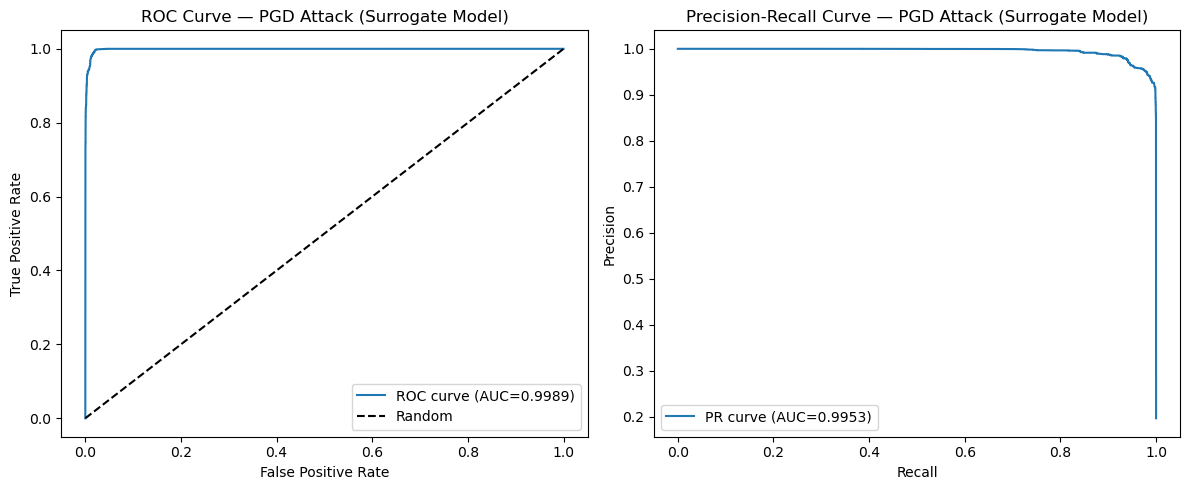

In [ ]:
# Evaluate PGD attack
evaluate_model(y_test, y_pred_adv_pgd, y_proba_adv_pgd,
               title="PGD Attack (Surrogate Model)", attack="PGD")

In [31]:
import copy

In [ ]:
##Some usefull functions 

def to_numpy(X):
    return X if isinstance(X, np.ndarray) else X.values

def to_1d_numpy(y):
    arr = y.values if hasattr(y, "values") else y
    return np.asarray(arr).reshape(-1)


### Data batching 
def make_batches(X, y, batch_size=512):
    X_np = to_numpy(X)
    y_np = to_1d_numpy(y)

    for start in range(0, len(X_np), batch_size):
        end = min(start + batch_size, len(X_np))
        yield X_np[start:end], y_np[start:end]


## compute metrics 
def compute_binary_metrics(model, X, y):
    y = to_1d_numpy(y)
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    return {
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall": recall_score(y, y_pred, zero_division=0),
        "f1": f1_score(y, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y, y_prob),
        "pr_auc": average_precision_score(y, y_prob),
    }


## Attack success rate evaluation 
def attack_success_rate(model, X_clean, X_adv, y_true):
    y_true = to_1d_numpy(y_true)

    pred_clean = model.predict(X_clean)
    pred_adv = model.predict(X_adv)

    correct_before = pred_clean == y_true
    if correct_before.sum() == 0:
        return 0.0

    broken_after = pred_adv[correct_before] != y_true[correct_before]
    return broken_after.mean()

## We retrain a new XGB model using the same parameters as the original model 
def retrain_xgb_like(model_template, X_train_new, y_train_new):
    new_model = XGBClassifier(**model_template.get_params())
    new_model.fit(X_train_new, y_train_new)
    return new_model


## Print metrics block 
def print_metrics_block(title, metrics_dict):
    print(f"\n{title}")
    print("-" * len(title))
    print(f"Precision : {metrics_dict['precision']:.4f}")
    print(f"Recall    : {metrics_dict['recall']:.4f}")
    print(f"F1-score  : {metrics_dict['f1']:.4f}")
    print(f"ROC-AUC   : {metrics_dict['roc_auc']:.4f}")
    print(f"PR-AUC    : {metrics_dict['pr_auc']:.4f}")

In [ ]:
## Main function to evaluate the model under attacks 

def evaluate_model_under_attacks(
    model,
    model_name,
    X_batch,
    y_batch,
    X_surrogate_ref,
    fgsm_attack_fn,
    pgd_attack_fn,
    fgsm_kwargs=None,
    pgd_kwargs=None,
    verbose=True
):
    if fgsm_kwargs is None:
        fgsm_kwargs = {}
    if pgd_kwargs is None:
        pgd_kwargs = {}

    # Clean
    clean_metrics = compute_binary_metrics(model, X_batch, y_batch)

    # FGSM
    X_adv_fgsm, _ = fgsm_attack_fn(
        victim_model=model,
        X_attack=X_batch,
        y_attack=y_batch,
        X_surrogate=X_surrogate_ref,
        **fgsm_kwargs
    )
    fgsm_metrics = compute_binary_metrics(model, X_adv_fgsm, y_batch)
    fgsm_asr = attack_success_rate(model, X_batch, X_adv_fgsm, y_batch)

    # PGD
    X_adv_pgd, _ = pgd_attack_fn(
        victim_model=model,
        X_attack=X_batch,
        y_attack=y_batch,
        X_surrogate=X_surrogate_ref,
        **pgd_kwargs
    )
    pgd_metrics = compute_binary_metrics(model, X_adv_pgd, y_batch)
    pgd_asr = attack_success_rate(model, X_batch, X_adv_pgd, y_batch)

    if verbose:
        print(f"\n==================== {model_name} ====================")
        print_metrics_block(f"{model_name} - CLEAN", clean_metrics)
        print_metrics_block(f"{model_name} - FGSM", fgsm_metrics)
        print(f"{model_name} - FGSM ASR : {fgsm_asr:.4f}")
        print_metrics_block(f"{model_name} - PGD", pgd_metrics)
        print(f"{model_name} - PGD ASR  : {pgd_asr:.4f}")

    return {
        "clean_metrics": clean_metrics,
        "fgsm_metrics": fgsm_metrics,
        "fgsm_asr": fgsm_asr,
        "pgd_metrics": pgd_metrics,
        "pgd_asr": pgd_asr,
        "X_adv_fgsm": X_adv_fgsm,
        "X_adv_pgd": X_adv_pgd,
    }

In [ ]:
## Dynamic defense using FGSM trigger like when the model is vulnerable to FGSM attack we retrain the model 

from numpy import dtype, ndarray


from typing import Any


def run_dynamic_defense_fgsm_trigger(
    initial_model,
    X_train_ref,
    y_train_ref,
    X_stream,
    y_stream,
    fgsm_attack_fn,
    pgd_attack_fn,
    fgsm_kwargs=None,
    pgd_kwargs=None,
    batch_size=512,
    trigger_drop_tol=0.05,      # retrain if FGSM F1 drops more than this from baseline
    min_fgsm_f1=None,           # optional absolute FGSM-F1 threshold
    ref_subset_size=3000,
    recent_memory_batches=3,
    verbose=True
):
    if fgsm_kwargs is None:
        fgsm_kwargs = {}
    if pgd_kwargs is None:
        pgd_kwargs = {}

    static_model = copy.deepcopy(initial_model)
    dynamic_model = copy.deepcopy(initial_model)

    X_ref = to_numpy(X_train_ref)
    y_ref = to_1d_numpy(y_train_ref)

    if len(X_ref) > ref_subset_size:
        idx = np.random.choice(len(X_ref), ref_subset_size, replace=False)
        X_ref_pool = X_ref[idx]
        y_ref_pool = y_ref[idx]
    else:
        X_ref_pool = X_ref.copy()
        y_ref_pool = y_ref.copy()

    baseline_fgsm_f1 = None

    clean_memory_X = []
    clean_memory_y = []
    fgsm_memory_X = []
    fgsm_memory_y = []

    records = []

    for batch_id, (X_batch, y_batch) in enumerate[tuple[ndarray[Any, Any] | Any, ndarray[Any, dtype]]](make_batches(X_stream, y_stream, batch_size=batch_size), start=1):

        if verbose:
            print("\n" + "=" * 70)
            print(f"BATCH {batch_id}")
            print("=" * 70)

        # -------------------------
        # STATIC MODEL
        # -------------------------
        static_eval = evaluate_model_under_attacks(
            model=static_model,
            model_name="STATIC XGBOOST",
            X_batch=X_batch,
            y_batch=y_batch,
            X_surrogate_ref=X_ref_pool,
            fgsm_attack_fn=fgsm_attack_fn,
            pgd_attack_fn=pgd_attack_fn,
            fgsm_kwargs=fgsm_kwargs,
            pgd_kwargs=pgd_kwargs,
            verbose=verbose
        )

        # -------------------------
        # DYNAMIC MODEL
        # -------------------------
        dynamic_eval = evaluate_model_under_attacks(
            model=dynamic_model,
            model_name="DYNAMIC XGBOOST",
            X_batch=X_batch,
            y_batch=y_batch,
            X_surrogate_ref=X_ref_pool,
            fgsm_attack_fn=fgsm_attack_fn,
            pgd_attack_fn=pgd_attack_fn,
            fgsm_kwargs=fgsm_kwargs,
            pgd_kwargs=pgd_kwargs,
            verbose=verbose
        )

        current_fgsm_f1 = dynamic_eval["fgsm_metrics"]["f1"]

        if baseline_fgsm_f1 is None:
            baseline_fgsm_f1 = current_fgsm_f1

        fgsm_drop = baseline_fgsm_f1 - current_fgsm_f1

        # -------------------------
        # MEMORY UPDATE
        # -------------------------
        clean_memory_X.append(X_batch.copy())
        clean_memory_y.append(y_batch.copy())
        fgsm_memory_X.append(dynamic_eval["X_adv_fgsm"].copy())
        fgsm_memory_y.append(y_batch.copy())

        if len(clean_memory_X) > recent_memory_batches:
            clean_memory_X.pop(0)
            clean_memory_y.pop(0)
            fgsm_memory_X.pop(0)
            fgsm_memory_y.pop(0)

        # -------------------------
        # TRIGGER
        # -------------------------
        retrain = False
        if fgsm_drop > trigger_drop_tol:
            retrain = True
        if min_fgsm_f1 is not None and current_fgsm_f1 < min_fgsm_f1:
            retrain = True

        if verbose:
            print(f"\nFGSM Trigger Check")
            print("------------------")
            print(f"Baseline FGSM F1 : {baseline_fgsm_f1:.4f}")
            print(f"Current FGSM F1  : {current_fgsm_f1:.4f}")
            print(f"FGSM F1 Drop     : {fgsm_drop:.4f}")
            print(f"Retrain Trigger  : {'YES' if retrain else 'NO'}")

        # -------------------------
        # RETRAIN DYNAMIC MODEL
        # -------------------------
        if retrain:
            X_clean_recent = np.vstack(clean_memory_X)
            y_clean_recent = np.hstack(clean_memory_y)

            X_fgsm_recent = np.vstack(fgsm_memory_X)
            y_fgsm_recent = np.hstack(fgsm_memory_y)

            X_retrain = np.vstack([X_ref_pool, X_clean_recent, X_fgsm_recent])
            y_retrain = np.hstack([y_ref_pool, y_clean_recent, y_fgsm_recent])

            if verbose:
                print("\nRetraining Dynamic XGBoost...")
                print(f"Retrain set shape: X={X_retrain.shape}, y={y_retrain.shape}")

            dynamic_model = retrain_xgb_like(dynamic_model, X_retrain, y_retrain)

        # -------------------------
        # SAVE RECORD
        # -------------------------
        records.append({
            "batch_id": batch_id,
            "n_samples": len(X_batch),

            "static_clean_f1": static_eval["clean_metrics"]["f1"],
            "static_fgsm_f1": static_eval["fgsm_metrics"]["f1"],
            "static_fgsm_asr": static_eval["fgsm_asr"],
            "static_pgd_f1": static_eval["pgd_metrics"]["f1"],
            "static_pgd_asr": static_eval["pgd_asr"],

            "dynamic_clean_f1": dynamic_eval["clean_metrics"]["f1"],
            "dynamic_fgsm_f1": dynamic_eval["fgsm_metrics"]["f1"],
            "dynamic_fgsm_asr": dynamic_eval["fgsm_asr"],
            "dynamic_pgd_f1": dynamic_eval["pgd_metrics"]["f1"],
            "dynamic_pgd_asr": dynamic_eval["pgd_asr"],

            "baseline_fgsm_f1": baseline_fgsm_f1,
            "fgsm_drop": fgsm_drop,
            "retrained": int(retrain),
        })

    history_df = pd.DataFrame(records)
    return history_df, static_model, dynamic_model

In [ ]:
## Call the dynamic defense function with our test parameters 

history_df, static_model_final, dynamic_model_final = run_dynamic_defense_fgsm_trigger(
    initial_model=model,
    X_train_ref=X_train_scaled,
    y_train_ref=y_train,
    X_stream=X_test_scaled,
    y_stream=y_test,
    fgsm_attack_fn=fgsm_attack_surrogate,
    pgd_attack_fn=pgd_attack_surrogate,
    fgsm_kwargs={
        "epsilon": 0.001,
        "surrogate_epochs": 10,
    },
    pgd_kwargs={
        "epsilon": 0.001,
        "alpha": 0.0001,
        "num_iter": 10,
        "surrogate_epochs": 10,
    },
    batch_size=512,
    trigger_drop_tol=0.05,
    min_fgsm_f1=0.80,
    ref_subset_size=3000,
    recent_memory_batches=3,
    verbose=True
)


history_df[[
    "batch_id",
    "static_clean_f1",
    "static_fgsm_f1",
    "static_pgd_f1",
    "dynamic_clean_f1",
    "dynamic_fgsm_f1",
    "dynamic_pgd_f1",
    "fgsm_drop",
    "retrained"
]]

print("Number of retrains:", history_df["retrained"].sum())




BATCH 1

==================== STATIC XGBOOST ====================

STATIC XGBOOST - CLEAN
----------------------
Precision : 0.9900
Recall    : 1.0000
F1-score  : 0.9950
ROC-AUC   : 0.9999
PR-AUC    : 0.9996

STATIC XGBOOST - FGSM
---------------------
Precision : 0.0000
Recall    : 0.0000
F1-score  : 0.0000
ROC-AUC   : 0.6484
PR-AUC    : 0.3307
STATIC XGBOOST - FGSM ASR : 0.1937

STATIC XGBOOST - PGD
--------------------
Precision : 0.0000
Recall    : 0.0000
F1-score  : 0.0000
ROC-AUC   : 0.8028
PR-AUC    : 0.6983
STATIC XGBOOST - PGD ASR  : 0.1937

==================== DYNAMIC XGBOOST ====================

DYNAMIC XGBOOST - CLEAN
-----------------------
Precision : 0.9900
Recall    : 1.0000
F1-score  : 0.9950
ROC-AUC   : 0.9999
PR-AUC    : 0.9996

DYNAMIC XGBOOST - FGSM
----------------------
Precision : 0.0000
Recall    : 0.0000
F1-score  : 0.0000
ROC-AUC   : 0.9830
PR-AUC    : 0.9248
DYNAMIC XGBOOST - FGSM ASR : 0.1937

DYNAMIC XGBOOST - PGD
---------------------
Precision : 0.000

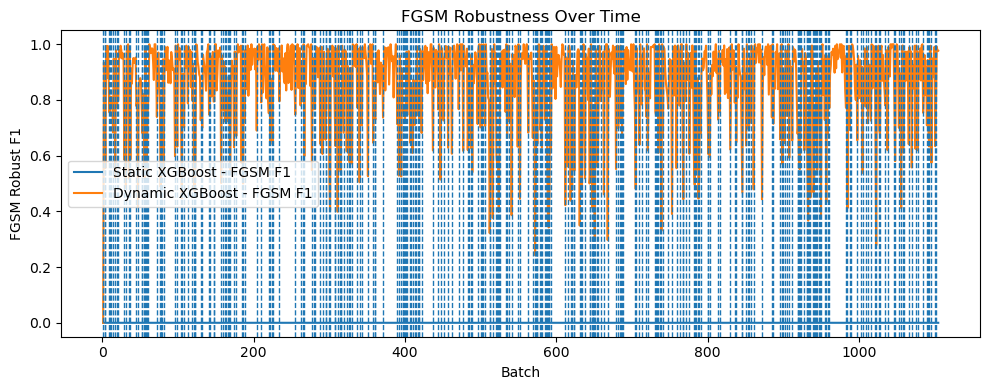

In [36]:
##FGSM Over time 


plt.figure(figsize=(10,4))
plt.plot(history_df["batch_id"], history_df["static_fgsm_f1"], label="Static XGBoost - FGSM F1")
plt.plot(history_df["batch_id"], history_df["dynamic_fgsm_f1"], label="Dynamic XGBoost - FGSM F1")

for b in history_df.loc[history_df["retrained"] == 1, "batch_id"]:
    plt.axvline(b, linestyle="--", linewidth=1)

plt.xlabel("Batch")
plt.ylabel("FGSM Robust F1")
plt.title("FGSM Robustness Over Time")
plt.legend()
plt.tight_layout()
plt.show()

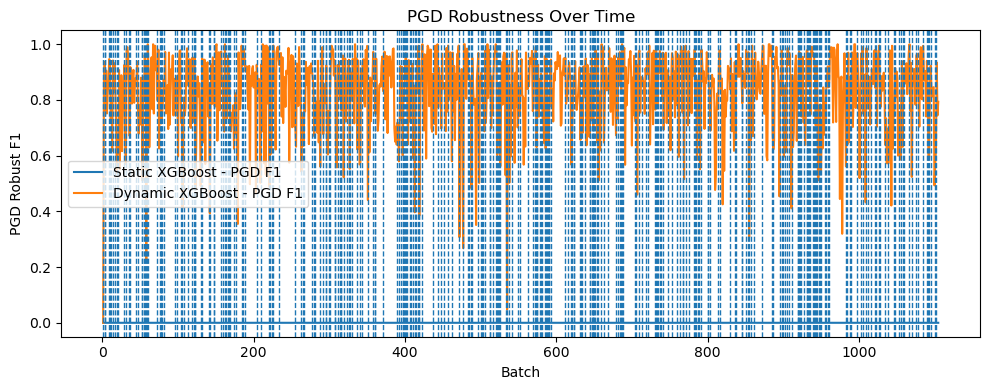

In [37]:
### PGD Over time 

plt.figure(figsize=(10,4))
plt.plot(history_df["batch_id"], history_df["static_pgd_f1"], label="Static XGBoost - PGD F1")
plt.plot(history_df["batch_id"], history_df["dynamic_pgd_f1"], label="Dynamic XGBoost - PGD F1")

for b in history_df.loc[history_df["retrained"] == 1, "batch_id"]:
    plt.axvline(b, linestyle="--", linewidth=1)

plt.xlabel("Batch")
plt.ylabel("PGD Robust F1")
plt.title("PGD Robustness Over Time")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
## Print the mean of the FGSM and PGD metrics for the dynamic and static models
print("FGSM Dynamic Mean:", history_df["dynamic_fgsm_f1"].mean())
print("PGD Dynamic Mean:", history_df["dynamic_pgd_f1"].mean())
print("FGSM Static Mean:", history_df["static_fgsm_f1"].mean())
print("PGD Static Mean:", history_df["static_pgd_f1"].mean())

FGSM Dynamic Mean: 0.8568260697072116
PGD Dynamic Mean: 0.8276925852356269
FGSM Static Mean: 0.0
PGD Static Mean: 0.0


In [ ]:
def evaluate_attack_candidate(
    model,
    attack_name,
    attack_fn,
    attack_params,
    X_batch,
    y_batch,
    X_surrogate_ref,
):
    X_adv, _ = attack_fn(
        victim_model=model,
        X_attack=X_batch,
        y_attack=y_batch,
        X_surrogate=X_surrogate_ref,
        **attack_params
    )

    metrics = compute_binary_metrics(model, X_adv, y_batch)
    asr = attack_success_rate(model, X_batch, X_adv, y_batch)

    return {
        "attack_name": attack_name,
        "attack_params": attack_params,
        "metrics": metrics,
        "asr": asr,
        "X_adv": X_adv,
    }

In [ ]:
def choose_best_attack(
    model,
    X_batch,
    y_batch,
    X_surrogate_ref,
    fgsm_attack_fn,
    pgd_attack_fn,
    fgsm_menu,
    pgd_menu,
    verbose=True,
):
    candidates = []

    # FGSM candidates
    for params in fgsm_menu:
        result = evaluate_attack_candidate(
            model=model,
            attack_name="FGSM",
            attack_fn=fgsm_attack_fn,
            attack_params=params,
            X_batch=X_batch,
            y_batch=y_batch,
            X_surrogate_ref=X_surrogate_ref,
        )
        candidates.append(result)

    # PGD candidates
    for params in pgd_menu:
        result = evaluate_attack_candidate(
            model=model,
            attack_name="PGD",
            attack_fn=pgd_attack_fn,
            attack_params=params,
            X_batch=X_batch,
            y_batch=y_batch,
            X_surrogate_ref=X_surrogate_ref,
        )
        candidates.append(result)

    # Choose strongest attack
    # Sort by:
    # 1. highest ASR
    # 2. lowest F1
    candidates_sorted = sorted(
        candidates,
        key=lambda d: (-d["asr"], d["metrics"]["f1"])
    )

    best = candidates_sorted[0]

    if verbose:
        print("\nATTACKER SEARCH RESULTS")
        print("-----------------------")
        for c in candidates_sorted:
            print(
                f"{c['attack_name']:>4} | "
                f"params={c['attack_params']} | "
                f"ASR={c['asr']:.4f} | "
                f"F1={c['metrics']['f1']:.4f}"
            )

        print("\nCHOSEN ATTACK")
        print("-------------")
        print(f"Attack : {best['attack_name']}")
        print(f"Params : {best['attack_params']}")
        print(f"ASR    : {best['asr']:.4f}")
        print(f"F1     : {best['metrics']['f1']:.4f}")

    return best, candidates_sorted

In [ ]:
def run_adaptive_attack_defense_game(
    initial_model,
    X_train_ref,
    y_train_ref,
    X_stream,
    y_stream,
    fgsm_attack_fn,
    pgd_attack_fn,
    fgsm_menu,
    pgd_menu,
    batch_size=512,
    trigger_asr=0.10,
    trigger_f1=0.80,
    ref_subset_size=3000,
    recent_memory_batches=3,
    verbose=True,
):
    static_model = copy.deepcopy(initial_model)
    dynamic_model = copy.deepcopy(initial_model)

    X_ref = to_numpy(X_train_ref)
    y_ref = to_1d_numpy(y_train_ref)

    if len(X_ref) > ref_subset_size:
        idx = np.random.choice(len(X_ref), ref_subset_size, replace=False)
        X_ref_pool = X_ref[idx]
        y_ref_pool = y_ref[idx]
    else:
        X_ref_pool = X_ref.copy()
        y_ref_pool = y_ref.copy()

    clean_memory_X = []
    clean_memory_y = []
    adv_memory_X = []
    adv_memory_y = []

    records = []

    for batch_id, (X_batch, y_batch) in enumerate(make_batches(X_stream, y_stream, batch_size=batch_size), start=1):

        if verbose:
            print("\n" + "=" * 80)
            print(f"BATCH {batch_id}")
            print("=" * 80)

        # -------------------------
        # CLEAN EVALUATION
        # -------------------------
        static_clean = compute_binary_metrics(static_model, X_batch, y_batch)
        dynamic_clean = compute_binary_metrics(dynamic_model, X_batch, y_batch)

        if verbose:
            print_metrics_block("STATIC XGBOOST - CLEAN", static_clean)
            print_metrics_block("DYNAMIC XGBOOST - CLEAN", dynamic_clean)

        # -------------------------
        # ATTACKER VS STATIC MODEL
        # -------------------------
        if verbose:
            print("\n" + "#" * 30)
            print("ATTACKER AGAINST STATIC XGBOOST")
            print("#" * 30)

        best_static_attack, static_candidates = choose_best_attack(
            model=static_model,
            X_batch=X_batch,
            y_batch=y_batch,
            X_surrogate_ref=X_ref_pool,
            fgsm_attack_fn=fgsm_attack_fn,
            pgd_attack_fn=pgd_attack_fn,
            fgsm_menu=fgsm_menu,
            pgd_menu=pgd_menu,
            verbose=verbose,
        )

        # -------------------------
        # ATTACKER VS DYNAMIC MODEL
        # -------------------------
        if verbose:
            print("\n" + "#" * 30)
            print("ATTACKER AGAINST DYNAMIC XGBOOST")
            print("#" * 30)

        best_dynamic_attack, dynamic_candidates = choose_best_attack(
            model=dynamic_model,
            X_batch=X_batch,
            y_batch=y_batch,
            X_surrogate_ref=X_ref_pool,
            fgsm_attack_fn=fgsm_attack_fn,
            pgd_attack_fn=pgd_attack_fn,
            fgsm_menu=fgsm_menu,
            pgd_menu=pgd_menu,
            verbose=verbose,
        )

        # -------------------------
        # DEFENDER MEMORY UPDATE
        # -------------------------
        clean_memory_X.append(X_batch.copy())
        clean_memory_y.append(y_batch.copy())
        adv_memory_X.append(best_dynamic_attack["X_adv"].copy())
        adv_memory_y.append(y_batch.copy())

        if len(clean_memory_X) > recent_memory_batches:
            clean_memory_X.pop(0)
            clean_memory_y.pop(0)
            adv_memory_X.pop(0)
            adv_memory_y.pop(0)

        # -------------------------
        # DEFENDER TRIGGER
        # -------------------------
        retrain = False
        chosen_dyn_f1 = best_dynamic_attack["metrics"]["f1"]
        chosen_dyn_asr = best_dynamic_attack["asr"]

        if chosen_dyn_asr > trigger_asr or chosen_dyn_f1 < trigger_f1:
            retrain = True

        if verbose:
            print("\nDEFENDER CHECK")
            print("--------------")
            print(f"Chosen attack       : {best_dynamic_attack['attack_name']}")
            print(f"Chosen params       : {best_dynamic_attack['attack_params']}")
            print(f"Chosen attack ASR   : {chosen_dyn_asr:.4f}")
            print(f"Chosen attack F1    : {chosen_dyn_f1:.4f}")
            print(f"Retrain Trigger     : {'YES' if retrain else 'NO'}")

        # -------------------------
        # DEFENDER RETRAIN
        # -------------------------
        if retrain:
            X_clean_recent = np.vstack(clean_memory_X)
            y_clean_recent = np.hstack(clean_memory_y)

            X_adv_recent = np.vstack(adv_memory_X)
            y_adv_recent = np.hstack(adv_memory_y)

            X_retrain = np.vstack([X_ref_pool, X_clean_recent, X_adv_recent])
            y_retrain = np.hstack([y_ref_pool, y_clean_recent, y_adv_recent])

            if verbose:
                print("\nRetraining dynamic XGBoost...")
                print(f"Retrain set shape: X={X_retrain.shape}, y={y_retrain.shape}")

            dynamic_model = retrain_xgb_like(dynamic_model, X_retrain, y_retrain)

        # -------------------------
        # RECORD
        # -------------------------
        records.append({
            "batch_id": batch_id,
            "n_samples": len(X_batch),

            "static_clean_f1": static_clean["f1"],
            "dynamic_clean_f1": dynamic_clean["f1"],

            "static_best_attack": best_static_attack["attack_name"],
            "static_best_attack_params": str(best_static_attack["attack_params"]),
            "static_best_attack_f1": best_static_attack["metrics"]["f1"],
            "static_best_attack_asr": best_static_attack["asr"],

            "dynamic_best_attack": best_dynamic_attack["attack_name"],
            "dynamic_best_attack_params": str(best_dynamic_attack["attack_params"]),
            "dynamic_best_attack_f1": best_dynamic_attack["metrics"]["f1"],
            "dynamic_best_attack_asr": best_dynamic_attack["asr"],

            "retrained": int(retrain),
        })

    history_df = pd.DataFrame(records)
    return history_df, static_model, dynamic_model

In [ ]:
fgsm_menu = [
    {"epsilon": 0.0005, "surrogate_epochs": 10},
    {"epsilon": 0.0010, "surrogate_epochs": 10},
    {"epsilon": 0.0050, "surrogate_epochs": 10},
]

pgd_menu = [
    {"epsilon": 0.0010, "alpha": 0.0001, "num_iter": 10, "surrogate_epochs": 10},
    {"epsilon": 0.0010, "alpha": 0.00005, "num_iter": 20, "surrogate_epochs": 10},
    {"epsilon": 0.0050, "alpha": 0.0005, "num_iter": 10, "surrogate_epochs": 10},
]

In [ ]:
history_df, static_model_final, dynamic_model_final = run_adaptive_attack_defense_game(
    initial_model=model,
    X_train_ref=X_train_scaled,
    y_train_ref=y_train,
    X_stream=X_test_scaled,
    y_stream=y_test,
    fgsm_attack_fn=fgsm_attack_surrogate,
    pgd_attack_fn=pgd_attack_surrogate,
    fgsm_menu=fgsm_menu,
    pgd_menu=pgd_menu,
    batch_size=512,
    trigger_asr=0.10,
    trigger_f1=0.80,
    ref_subset_size=3000,
    recent_memory_batches=3,
    verbose=True,
)

In [ ]:
history_df.head()

In [ ]:
print("Static attacker choices:")
print(history_df["static_best_attack"].value_counts())

print("\nDynamic attacker choices:")
print(history_df["dynamic_best_attack"].value_counts())

In [ ]:
print("Average static chosen-attack F1:", history_df["static_best_attack_f1"].mean())
print("Average dynamic chosen-attack F1:", history_df["dynamic_best_attack_f1"].mean())

print("Average static chosen-attack ASR:", history_df["static_best_attack_asr"].mean())
print("Average dynamic chosen-attack ASR:", history_df["dynamic_best_attack_asr"].mean())

In [ ]:
print("Number of retrains:", history_df["retrained"].sum())

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(history_df["batch_id"], history_df["static_best_attack_f1"], label="Static - strongest attack F1")
plt.plot(history_df["batch_id"], history_df["dynamic_best_attack_f1"], label="Dynamic - strongest attack F1")

for b in history_df.loc[history_df["retrained"] == 1, "batch_id"]:
    plt.axvline(b, linestyle="--", linewidth=1)

plt.xlabel("Batch")
plt.ylabel("Robust F1 under chosen attack")
plt.title("Adaptive Attacker vs Defender Over Time")
plt.legend()
plt.tight_layout()
plt.show()